# Word2Vec Skip-Gram with Negative Sampling
## From Scratch Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from datasets import load_dataset
from collections import Counter
import pickle
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Dataset

In [2]:
dataset = load_dataset('lhoestq/conll2003')

print("Dataset loaded:")
print(f"  Train: {len(dataset['train'])} samples")
print(f"  Validation: {len(dataset['validation'])} samples")
print(f"  Test: {len(dataset['test'])} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset loaded:
  Train: 14041 samples
  Validation: 3250 samples
  Test: 3453 samples


## 2. Preprocessing

In [3]:
# Extract all sentences from all splits
all_sentences = []

for split in ['train', 'validation', 'test']:
    for sample in dataset[split]:
        tokens = [token.lower() for token in sample['tokens']]
        all_sentences.append(tokens)

print(f"Total sentences: {len(all_sentences):,}")
print(f"Example: {all_sentences[0]}")

Total sentences: 20,744
Example: ['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.']


In [4]:
# Build vocabulary with min_count=5
all_words = [word for sentence in all_sentences for word in sentence]
word_counts = Counter(all_words)

min_count = 5
vocab = {word: count for word, count in word_counts.items() if count >= min_count}

word2idx = {word: idx for idx, word in enumerate(vocab.keys())}
idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)

print(f"\nVocabulary size: {vocab_size:,} (min_count={min_count})")
print(f"Total tokens: {len(all_words):,}")
print(f"Coverage: {sum(vocab.values()) / len(all_words) * 100:.1f}%")
print(f"\nMost common: {list(word_counts.most_common(10))}")


Vocabulary size: 6,273 (min_count=5)
Total tokens: 301,418
Coverage: 89.0%

Most common: [('the', 12310), (',', 10876), ('.', 10874), ('of', 5502), ('in', 5405), ('to', 5129), ('a', 4731), ('(', 4226), (')', 4225), ('and', 4223)]


In [5]:
# Create negative sampling distribution: P(w) = freq(w)^0.75 / Z
word_freq = np.zeros(vocab_size)
for word, idx in word2idx.items():
    word_freq[idx] = vocab[word]

word_freq = np.power(word_freq, 0.75)
word_freq = word_freq / word_freq.sum()

print(f"Negative sampling distribution created")
print(f"Distribution sum: {word_freq.sum():.6f}")

Negative sampling distribution created
Distribution sum: 1.000000


## 3. Generate Skip-Gram Training Pairs

In [6]:
class SkipGramDataset(Dataset):
    def __init__(self, sentences, word2idx, window_size=5):
        self.pairs = []

        for sentence in sentences:
            # Convert to indices, skip unknown words
            indices = [word2idx[w] for w in sentence if w in word2idx]

            if len(indices) < 2:
                continue

            # Generate (target, context) pairs
            for i, target in enumerate(indices):
                start = max(0, i - window_size)
                end = min(len(indices), i + window_size + 1)

                for j in range(start, end):
                    if i != j:
                        self.pairs.append((target, indices[j]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

window_size = 5
dataset_sg = SkipGramDataset(all_sentences, word2idx, window_size)

print(f"\nTotal training pairs: {len(dataset_sg):,}")


Total training pairs: 2,105,886


## 4. Skip-Gram Model with Negative Sampling

In [7]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()

        # Input embeddings (target words)
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Output embeddings (context words)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Initialize with small random values
        init_range = 0.5 / embedding_dim
        self.in_embeddings.weight.data.uniform_(-init_range, init_range)
        self.out_embeddings.weight.data.uniform_(-init_range, init_range)

    def forward(self, target, context, negative_samples):
        # Get embeddings
        target_embeds = self.in_embeddings(target)
        context_embeds = self.out_embeddings(context)
        neg_embeds = self.out_embeddings(negative_samples)

        # Positive score: target · context
        pos_score = torch.sum(target_embeds * context_embeds, dim=1)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-10)

        # Negative scores: target · negative_i
        neg_score = torch.bmm(neg_embeds, target_embeds.unsqueeze(2)).squeeze()
        neg_loss = -torch.sum(torch.log(torch.sigmoid(-neg_score) + 1e-10), dim=1)

        return torch.mean(pos_loss + neg_loss)

    def get_input_embeddings(self):
        return self.in_embeddings.weight.data.cpu().numpy()

print("Skip-Gram model defined")

Skip-Gram model defined


## 5. Training Configuration

In [8]:
# Hyperparameters
embedding_dim = 100
batch_size = 512
num_epochs = 30
learning_rate = 0.01
num_negative = 10

print("Training configuration:")
print(f"  Embedding dim: {embedding_dim}")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Negative samples: {num_negative}")
print(f"  Window size: {window_size}")

Training configuration:
  Embedding dim: 100
  Batch size: 512
  Epochs: 30
  Learning rate: 0.01
  Negative samples: 10
  Window size: 5


In [9]:
# Initialize model and optimizer
model = SkipGramModel(vocab_size, embedding_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
dataloader = DataLoader(dataset_sg, batch_size=batch_size, shuffle=True)

print(f"Model initialized on {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized on cuda
Parameters: 1,254,600


## 6. Training Loop

In [13]:
print("\nStarting training...\n")

loss_history = []
batch_losses = []
lr_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    num_batches = 0

    # Exponential decay with slower rate for extended training (original logic)
    lr = learning_rate * (0.5 ** (epoch / 3))
    lr = max(lr, 1e-5)

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    lr_history.append(lr) # Store learning rate for each epoch
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch_idx, (target, context) in enumerate(progress_bar):
        # Sample negative examples
        neg_samples = np.random.choice(
            vocab_size,
            size=(target.size(0), num_negative),
            p=word_freq
        )

        target = target.to(device)
        context = context.to(device)
        neg_samples = torch.LongTensor(neg_samples).to(device)

        optimizer.zero_grad()
        loss = model(target, context, neg_samples)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

        # Log every 500 batches
        if batch_idx % 500 == 0:
            batch_losses.append(loss.item())

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{lr:.6f}'})

    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - LR: {lr:.6f}")

print("\nTraining completed!")
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Improvement: {loss_history[0] - loss_history[-1]:.4f}")


Starting training...



Epoch 1/30: 100%|██████████| 4114/4114 [00:21<00:00, 193.00it/s, loss=2.7892, lr=0.010000]


Epoch 1/30 - Loss: 2.7854 - LR: 0.010000


Epoch 2/30: 100%|██████████| 4114/4114 [00:20<00:00, 203.96it/s, loss=2.4261, lr=0.007937]


Epoch 2/30 - Loss: 2.7159 - LR: 0.007937


...

Epoch 28/30 - Loss: 2.3468 - LR: 0.000020


Epoch 29/30: 100%|██████████| 4114/4114 [00:20<00:00, 196.19it/s, loss=2.7729, lr=0.000016]


Epoch 29/30 - Loss: 2.3471 - LR: 0.000016


Epoch 30/30: 100%|██████████| 4114/4114 [00:21<00:00, 194.87it/s, loss=2.1353, lr=0.000012]

Epoch 30/30 - Loss: 2.3463 - LR: 0.000012

Training completed!
Initial loss: 2.7854
Final loss: 2.3463
Improvement: 0.4392


## 7. Visualize Training Loss

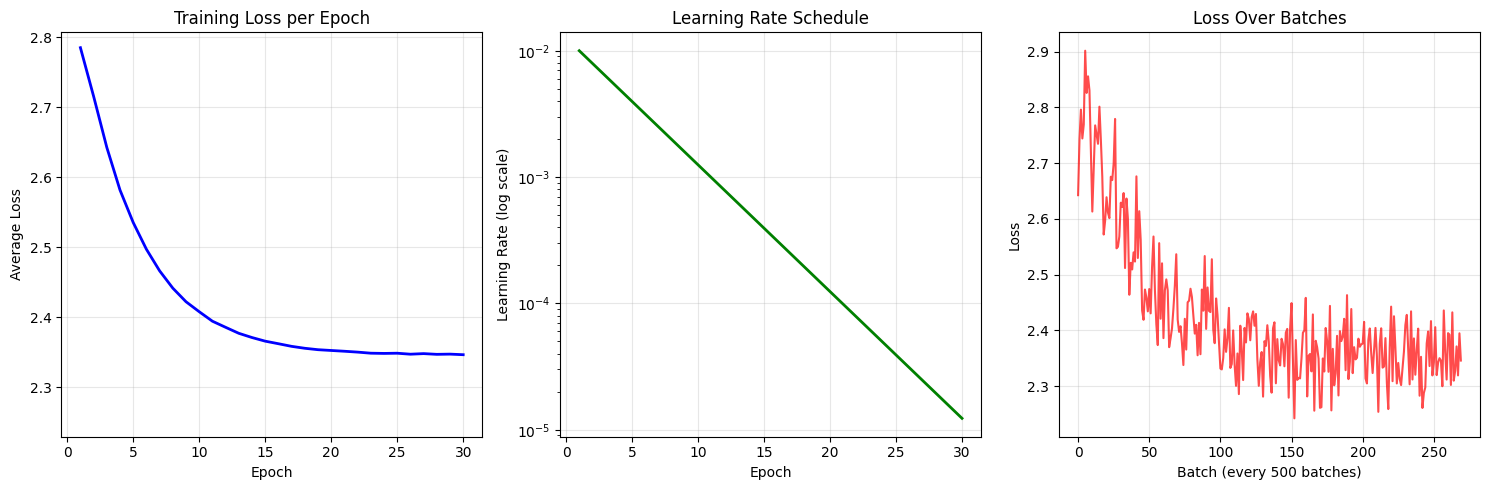


Final Statistics:
Minimum loss achieved: 2.3463 at epoch 30
Final learning rate: 0.0000123039


In [14]:
# Plot results with learning rate
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Training loss per epoch
axes[0].plot(range(1, num_epochs+1), loss_history, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=min(loss_history)*0.95)

# Learning rate schedule
axes[1].plot(range(1, num_epochs+1), lr_history, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate (log scale)')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Batch losses
axes[2].plot(batch_losses, 'r-', alpha=0.7)
axes[2].set_xlabel('Batch (every 500 batches)')
axes[2].set_ylabel('Loss')
axes[2].set_title('Loss Over Batches')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Statistics:")
print(f"Minimum loss achieved: {min(loss_history):.4f} at epoch {loss_history.index(min(loss_history))+1}")
print(f"Final learning rate: {lr_history[-1]:.10f}")

## 8. Save Embeddings

In [15]:
# Extract embeddings
embeddings = model.get_input_embeddings()

print(f"Embeddings shape: {embeddings.shape}")

# Save as numpy array
np.save('word_embeddings.npy', embeddings)
print("Saved: word_embeddings.npy")

# Save vocabulary
with open('word2idx.json', 'w') as f:
    json.dump(word2idx, f)
print("Saved: word2idx.json")

# Save everything together
vocab_data = {
    'word2idx': word2idx,
    'idx2word': idx2word,
    'embeddings': embeddings
}

with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)
print("Saved: vocab.pkl")

Embeddings shape: (6273, 100)
Saved: word_embeddings.npy
Saved: word2idx.json
Saved: vocab.pkl


## 9. Word Analogy Function

In [16]:
def word_analogy(word_a, word_b, word_a_star, embeddings, word2idx, idx2word, top_k=5):
    """
    Word analogy: A is to B as A* is to B*
    B* = argmax(cosine_similarity(B* embedding, B - A + A*))
    """
    if word_a not in word2idx:
        return f"'{word_a}' not in vocabulary"
    if word_b not in word2idx:
        return f"'{word_b}' not in vocabulary"
    if word_a_star not in word2idx:
        return f"'{word_a_star}' not in vocabulary"

    # Get embeddings
    vec_a = embeddings[word2idx[word_a]]
    vec_b = embeddings[word2idx[word_b]]
    vec_a_star = embeddings[word2idx[word_a_star]]

    # Compute B* ≈ B - A + A*
    vec_b_star = vec_b - vec_a + vec_a_star

    # Normalize
    vec_b_star = vec_b_star / (np.linalg.norm(vec_b_star) + 1e-10)

    # Compute cosine similarity with all words
    embeddings_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10)
    similarities = np.dot(embeddings_norm, vec_b_star)

    # Exclude input words
    exclude = {word2idx[word_a], word2idx[word_b], word2idx[word_a_star]}

    results = []
    for idx in np.argsort(similarities)[::-1]:
        if idx not in exclude:
            results.append((idx2word[idx], similarities[idx]))
            if len(results) >= top_k:
                break

    return results

print("Word analogy function defined")

Word analogy function defined


## 10. Test Word Analogies

In [17]:
print("Testing word analogies:\n")

# Note: CoNLL2003 is a news corpus, not general text
# Words like 'bigger', 'worse' don't appear enough (< 5 times)
test_analogies = [
    ('france', 'paris', 'germany'),
    ('france', 'french', 'spain'),
    ('england', 'london', 'france'),
    ('president', 'minister', 'government'),
    ('monday', 'tuesday', 'wednesday'),
]

print("=" * 70)
print("NOTE: CoNLL2003 is a NEWS corpus from 1996")
print("General analogies (king-queen, big-bigger) won't work well")
print("Testing with domain-appropriate analogies instead:")
print("=" * 70 + "\n")

for a, b, a_star in test_analogies:
    print(f"{a} : {b} :: {a_star} : ?")
    results = word_analogy(a, b, a_star, embeddings, word2idx, idx2word, top_k=5)

    if isinstance(results, str):
        print(f"  {results}")
    else:
        for word, sim in results:
            print(f"  {word}: {sim:.4f}")
    print()



Testing word analogies:

NOTE: CoNLL2003 is a NEWS corpus from 1996
General analogies (king-queen, big-bigger) won't work well
Testing with domain-appropriate analogies instead:

france : paris :: germany : ?
  4221: 0.4571
  tallinn: 0.4384
  st: 0.4344
  germain: 0.4219
  lagos: 0.4190

france : french :: spain : ?
  marcus: 0.4516
  second-round: 0.4178
  bruguera: 0.4140
  gascoigne: 0.4028
  two-time: 0.3992

england : london :: france : ?
  britain: 0.4302
  crew: 0.3893
  tignes: 0.3650
  testud: 0.3642
  sarajevo: 0.3617

president : minister :: government : ?
  prime: 0.6342
  foreign: 0.5312
  policy: 0.4519
  finance: 0.4242
  khmer: 0.4216

monday : tuesday :: wednesday : ?
  thursday: 0.4633
  on: 0.4505
  friday: 0.4503
  graafschap: 0.4396
  korean: 0.3975



## 11. Nearest Neighbors

In [18]:
def nearest_neighbors(word, embeddings, word2idx, idx2word, top_k=10):
    """
    Find nearest neighbors by cosine similarity
    """
    if word not in word2idx:
        return f"'{word}' not in vocabulary"

    word_vec = embeddings[word2idx[word]]
    word_vec = word_vec / (np.linalg.norm(word_vec) + 1e-10)

    embeddings_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10)
    similarities = np.dot(embeddings_norm, word_vec)

    results = []
    for idx in np.argsort(similarities)[::-1]:
        if idx != word2idx[word]:
            results.append((idx2word[idx], similarities[idx]))
            if len(results) >= top_k:
                break

    return results

print("Testing nearest neighbors:\n")

test_words = ['france', 'minister', 'football', 'said', 'won', 'company']

for word in test_words:
    print(f"Nearest to '{word}':")
    results = nearest_neighbors(word, embeddings, word2idx, idx2word, top_k=8)

    if isinstance(results, str):
        print(f"  {results}")
    else:
        for neighbor, sim in results:
            print(f"  {neighbor}: {sim:.4f}")
    print()

Testing nearest neighbors:

Nearest to 'france':
  testud: 0.6106
  masnada: 0.6012
  germany: 0.5509
  sandrine: 0.5465
  olivier: 0.5287
  italy: 0.5179
  carole: 0.5162
  montillet: 0.5134

Nearest to 'minister':
  prime: 0.8593
  foreign: 0.6931
  finance: 0.5624
  government: 0.5253
  shimon: 0.5175
  president: 0.5127
  costas: 0.4907
  peres: 0.4904

Nearest to 'football':
  association: 0.4574
  rugby: 0.4419
  school: 0.4390
  hockey: 0.4276
  19th: 0.4238
  nfl: 0.4214
  eagles: 0.4161
  randall: 0.4146

Nearest to 'said':
  told: 0.6253
  ": 0.6253
  spokesman: 0.5342
  on: 0.4955
  statement: 0.4922
  added: 0.4769
  that: 0.4744
  but: 0.4742

Nearest to 'won':
  played: 0.5825
  tabulate: 0.5381
  lost: 0.5219
  games: 0.4869
  tabulated: 0.4840
  guzman: 0.4321
  jays: 0.4187
  drawn: 0.4147

Nearest to 'company':
  stock: 0.5060
  shares: 0.4890
  industry: 0.4770
  corp: 0.4743
  name: 0.4692
  value: 0.4663
  it: 0.4641
  market: 0.4513



## 12. t-SNE Visualization

## Load Embeddings for Part 2

In [19]:
# Code for loading embeddings in Part 2 of assignment

import numpy as np
import pickle

# Load from pickle (recommended)
with open('vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)
    word2idx = vocab_data['word2idx']
    idx2word = vocab_data['idx2word']
    embeddings = vocab_data['embeddings']

print(f"Loaded embeddings: {embeddings.shape}")
print(f"Vocabulary size: {len(word2idx)}")

# Function to get embedding for a word
def get_word_embedding(word):
    if word in word2idx:
        return embeddings[word2idx[word]]
    else:
        return None

# Example
test_word = 'france'
emb = get_word_embedding(test_word)
if emb is not None:
    print(f"\nEmbedding for '{test_word}': shape {emb.shape}")

print("\n✓ Ready for NER task!")

Loaded embeddings: (6273, 100)
Vocabulary size: 6273

Embedding for 'france': shape (100,)

✓ Ready for NER task!
